# FLAMINGO I/O demo (h5py-only)

Demonstrates reading FLAMINGO snapshot particles, SOAP-HBT halo catalogs, and
halo member particles with **plain h5py** — no `swiftsimio`.

**Why not swiftsimio:** the current swiftsimio release imports `numpy.vecdot`,
which only exists in NumPy >= 2.0. The cosmodesi DR1 stack pins NumPy 1.x, so
`import swiftsimio` fails with
`ImportError: cannot import name 'vecdot' from 'numpy'`.
Plain h5py works fine and matches how this repo already reads SIMBA.

**Data layout** (one snapshot, 67 = z of 0.5, three feedback variants) under
`/pscratch/sd/r/rhliu/simulations/FLAMINGO/L1_m9/{variant}/`:

- `snapshots/flamingo_0067/flamingo_0067.hdf5` — small *virtual* HDF5 file whose
  datasets transparently stitch together the 64 chunk files in
  `swift_snapshot_0067/` **and** the halo-membership files in `membership_0067/`
  (so each particle carries `HaloCatalogueIndex`, `GroupNr_bound`, `Rank_bound`,
  `FOFGroupIDs`).
- `SOAP-HBT/halo_properties_0067.hdf5` — SOAP halo catalog (~17.7M subhalos).


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

FLAMINGO_BASE = '/pscratch/sd/r/rhliu/simulations/FLAMINGO/L1_m9'
VARIANTS = ['L1_m9', 'fgas-8sigma', 'Jet_fgas-4sigma']  # fiducial + 2 feedback variants
SNAPSHOT = 67


def snap_file(variant, snapshot=SNAPSHOT):
    """Path to the virtual snapshot file for a FLAMINGO variant."""
    return f'{FLAMINGO_BASE}/{variant}/snapshots/flamingo_{snapshot:04d}/flamingo_{snapshot:04d}.hdf5'


def soap_file(variant, snapshot=SNAPSHOT):
    """Path to the SOAP-HBT halo catalog for a FLAMINGO variant."""
    return f'{FLAMINGO_BASE}/{variant}/SOAP-HBT/halo_properties_{snapshot:04d}.hdf5'


variant = 'L1_m9'  # fiducial run used for the main demo
print(snap_file(variant))
print(soap_file(variant))


/pscratch/sd/r/rhliu/simulations/FLAMINGO/L1_m9/L1_m9/snapshots/flamingo_0067/flamingo_0067.hdf5
/pscratch/sd/r/rhliu/simulations/FLAMINGO/L1_m9/L1_m9/SOAP-HBT/halo_properties_0067.hdf5


## 1. Header, cosmology, and units

FLAMINGO/SWIFT internal units: length = 1 comoving Mpc, mass = 1e10 Msun —
**no factors of h anywhere** (unlike Gadget-style TNG/SIMBA outputs).

One gotcha: in the virtual file, `NumPart_Total` overflows 32 bits; the true
counts are in `NumPart_ThisFile` (or `NumPart_Total + 2^32 * NumPart_Total_HighWord`).


In [2]:
with h5py.File(snap_file(variant), 'r') as f:
    print('Top-level groups:')
    print(sorted(f.keys()))
    header = dict(f['Header'].attrs.items())
    cosmo = dict(f['Cosmology'].attrs.items())
    units = dict(f['Units'].attrs.items())

boxsize = float(header['BoxSize'][0])  # comoving Mpc (no h)
z = float(cosmo['Redshift'][0])
h = float(cosmo['h'][0])
Om = float(cosmo['Omega_m'][0])

print()
print(f'BoxSize      = {boxsize:.4f} cMpc  (= {boxsize * h:.1f} cMpc/h)')
print(f'Redshift     = {z:.4f}, scale factor a = {float(header["Scale-factor"][0]):.6f}')
print(f'h            = {h}, Omega_m = {Om}, Omega_b = {float(cosmo["Omega_b"][0])}')
print(f'MassTable    = {header["MassTable"]}  (all zeros -> every ptype has a per-particle Masses field)')
print()
print('Unit system (CGS):')
print(f'  U_L = {float(units["Unit length in cgs (U_L)"][0]):.6e} cm  (= 1 comoving Mpc)')
print(f'  U_M = {float(units["Unit mass in cgs (U_M)"][0]):.6e} g   (= 1e10 Msun)')


Top-level groups:
['BHParticles', 'Cells', 'Code', 'Cosmology', 'DMParticles', 'GasParticles', 'GravityScheme', 'Header', 'HydroScheme', 'ICs_parameters', 'InternalCodeUnits', 'NeutrinoParticles', 'Parameters', 'PartType0', 'PartType1', 'PartType4', 'PartType5', 'PartType6', 'PhysicalConstants', 'Policy', 'StarsParticles', 'StarsScheme', 'SubgridScheme', 'Units', 'UnusedParameters']

BoxSize      = 1000.0000 cMpc  (= 681.0 cMpc/h)
Redshift     = 0.5000, scale factor a = 0.666667
h            = 0.681, Omega_m = 0.30461099999999997, Omega_b = 0.0486
MassTable    = [0. 0. 0. 0. 0. 0. 0.]  (all zeros -> every ptype has a per-particle Masses field)

Unit system (CGS):
  U_L = 3.085678e+24 cm  (= 1 comoving Mpc)
  U_M = 1.988410e+43 g   (= 1e10 Msun)


In [3]:
# The NumPart_Total 32-bit overflow
n_file = header['NumPart_ThisFile'].astype(np.int64)
n_tot32 = header['NumPart_Total'].astype(np.int64)
n_high = header['NumPart_Total_HighWord'].astype(np.int64)
n_tot = n_tot32 + (n_high << 32)

ptype_names = ['gas (0)', 'DM (1)', '- (2)', '- (3)', 'stars (4)', 'BH (5)', 'neutrino (6)']
print(f'{"ptype":>14} {"NumPart_Total":>15} {"+HighWord<<32":>15} {"NumPart_ThisFile":>17}')
for i, name in enumerate(ptype_names):
    print(f'{name:>14} {n_tot32[i]:>15d} {n_tot[i]:>15d} {n_file[i]:>17d}')
assert np.all(n_tot == n_file), 'HighWord-corrected totals should equal ThisFile counts'
print('\n-> use NumPart_ThisFile (or apply the HighWord) for true particle counts.')


         ptype   NumPart_Total   +HighWord<<32  NumPart_ThisFile
       gas (0)      1069132157      5364099453        5364099453
        DM (1)      1537032704      5832000000        5832000000
         - (2)               0               0                 0
         - (3)               0               0                 0
     stars (4)       451343758       451343758         451343758
        BH (5)        11759094        11759094          11759094
  neutrino (6)      1000000000      1000000000        1000000000

-> use NumPart_ThisFile (or apply the HighWord) for true particle counts.


### Dataset unit attributes and conversion to repo conventions

Every SWIFT dataset carries attributes describing its units: `U_*` exponents,
`a-scale exponent` (comoving factor), `h-scale exponent` (always 0 in FLAMINGO),
and ready-made CGS conversion factors.

This repo's convention (set by IllustrisTNG/SIMBA loading) is **ckpc/h** for
positions and **Msun/h** for masses, so:

| quantity | FLAMINGO native | -> repo convention |
|---|---|---|
| positions | cMpc | `x * 1000 * h` -> ckpc/h |
| masses | 1e10 Msun | `m * 1e10 * h` -> Msun/h |
| box size | cMpc | `L * 1000 * h` -> ckpc/h |


In [4]:
with h5py.File(snap_file(variant), 'r') as f:
    ds = f['PartType0/Coordinates']
    print(f'PartType0/Coordinates: shape {ds.shape}, dtype {ds.dtype}, virtual={ds.is_virtual}')
    for k in ['Description', 'Expression for physical CGS units',
              'U_L exponent', 'a-scale exponent', 'h-scale exponent',
              'Conversion factor to CGS (not including cosmological corrections)']:
        print(f'  {k}: {ds.attrs[k]}')

# Conversion factors to this repo's conventions (ckpc/h, Msun/h)
POS_TO_CKPC_H = 1000.0 * h   # cMpc -> ckpc/h
MASS_TO_MSUN_H = 1e10 * h    # 1e10 Msun -> Msun/h
print(f'\nPOS_TO_CKPC_H = {POS_TO_CKPC_H}, MASS_TO_MSUN_H = {MASS_TO_MSUN_H:.4g}')
print(f'BoxSize in repo units: {boxsize * POS_TO_CKPC_H:.1f} ckpc/h')


PartType0/Coordinates: shape (5364099453, 3), dtype float64, virtual=True
  Description: b'Co-moving positions of the particles'
  Expression for physical CGS units: b'a U_L  [ cm ]'
  U_L exponent: [1.]
  a-scale exponent: [1.]
  h-scale exponent: [0.]
  Conversion factor to CGS (not including cosmological corrections): [3.08567758e+24]

POS_TO_CKPC_H = 681.0, MASS_TO_MSUN_H = 6.81e+09
BoxSize in repo units: 681000.0 ckpc/h


## 2. Reading simulation particles

The full snapshot has 5.4 billion gas particles (~130 GB of coordinates alone),
so we never read a full array. The `Cells` group provides spatial indexing:
the box is divided into 32^3 cells of 31.25 cMpc, and for each cell and particle
type it stores the offset and count into the (virtual) snapshot datasets. Reading
a spatial region = reading the slices of the cells that cover it.


In [5]:
with h5py.File(snap_file(variant), 'r') as f:
    cell_centres = f['Cells/Centres'][:]                      # cMpc
    cell_meta = dict(f['Cells/Meta-data'].attrs.items())
    # Sanity check: all cell data lives in "file 0" == the virtual file itself
    for pt in ['PartType0', 'PartType1', 'PartType4', 'PartType5']:
        assert np.all(f['Cells/Files/' + pt][:] == 0)

cell_size = cell_meta['size']  # cMpc per cell, per axis
print(f'{cell_meta["nr_cells"][0]} cells, grid {cell_meta["dimension"]}, cell size {cell_size} cMpc')


def read_cells(f, ptype, cell_idx, fields):
    """Read the given fields for all particles in the given cells.

    Merges contiguous cell slices to minimize the number of HDF5 reads.

    Args:
        f (h5py.File): Open virtual snapshot file.
        ptype (str): Particle group, e.g. 'PartType0'.
        cell_idx (np.ndarray): Indices of cells to read.
        fields (list): Dataset names to read, e.g. ['Coordinates', 'Masses'].

    Returns:
        dict: field name -> concatenated array over the requested cells.
    """
    offsets = f['Cells/OffsetsInFile/' + ptype][:][cell_idx]
    counts = f['Cells/Counts/' + ptype][:][cell_idx]
    order = np.argsort(offsets)
    offsets, counts = offsets[order], counts[order]
    ranges = []
    start, end = offsets[0], offsets[0] + counts[0]
    for o, c in zip(offsets[1:], counts[1:]):
        if o == end:
            end = o + c
        else:
            ranges.append((start, end))
            start, end = o, o + c
    ranges.append((start, end))
    out = {}
    for field in fields:
        ds = f[f'{ptype}/{field}']
        out[field] = np.concatenate([ds[s:e] for s, e in ranges])
    return out


32768 cells, grid [32 32 32], cell size [31.25000002 31.25000002 31.25000002] cMpc


In [6]:
# Read one 31.25 cMpc slab (all cells with the lowest x index): gas coordinates + masses
slab_cells = np.where(cell_centres[:, 0] < cell_size[0])[0]
print(f'{len(slab_cells)} cells in slab')

with h5py.File(snap_file(variant), 'r') as f:
    gas_slab = read_cells(f, 'PartType0', slab_cells, ['Coordinates', 'Masses'])

n_gas = len(gas_slab['Masses'])
print(f'read {n_gas:,} gas particles '
      f'({gas_slab["Coordinates"].nbytes / 1e9:.2f} GB coords, dtype {gas_slab["Coordinates"].dtype})')
print(f'expected ~N_gas/32 = {n_file[0] / 32:,.0f}')
# Cells store particles by their position at the last domain rebuild, so a tiny
# fraction sit slightly outside the nominal slab (incl. periodic wrap-around).
frac_in = np.mean(gas_slab['Coordinates'][:, 0] < cell_size[0])
print(f'{frac_in:.2%} of the read particles lie inside the nominal slab x-range; '
      f'the rest drifted slightly across cell edges (or wrapped periodically)')
print(f'mean gas particle mass: {gas_slab["Masses"].mean() * 1e10:.3e} Msun '
      f'({gas_slab["Masses"].mean() * MASS_TO_MSUN_H:.3e} Msun/h)')


1024 cells in slab


read 164,806,093 gas particles (3.96 GB coords, dtype float64)
expected ~N_gas/32 = 167,628,108


100.00% of the read particles lie inside the nominal slab x-range; the rest drifted slightly across cell edges (or wrapped periodically)
mean gas particle mass: 1.099e+09 Msun (7.481e+08 Msun/h)


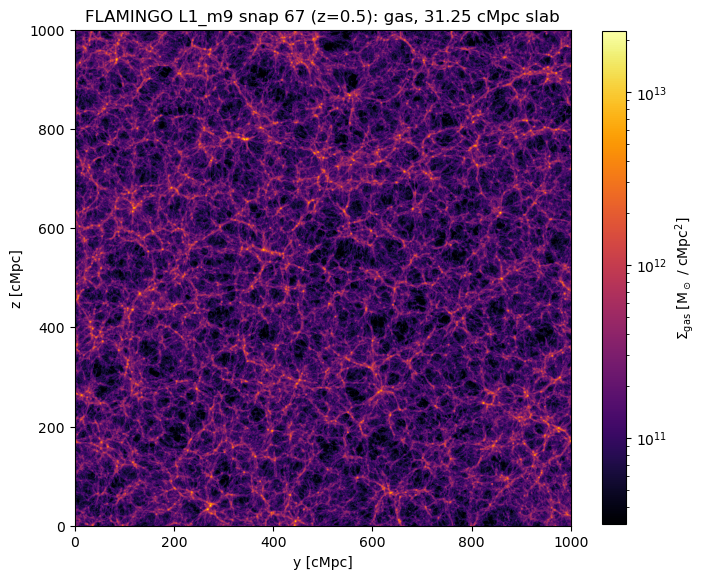

In [7]:
# Projected gas surface density of the slab (y-z plane)
nbins = 1000
sigma, ye, ze = np.histogram2d(gas_slab['Coordinates'][:, 1], gas_slab['Coordinates'][:, 2],
                               bins=nbins, range=[[0, boxsize], [0, boxsize]],
                               weights=gas_slab['Masses'])
sigma *= 1e10 / (boxsize / nbins) ** 2  # Msun / cMpc^2

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(sigma.T, origin='lower', extent=[0, boxsize, 0, boxsize],
               norm=LogNorm(vmin=np.percentile(sigma[sigma > 0], 1)), cmap='inferno')
ax.set_xlabel('y [cMpc]')
ax.set_ylabel('z [cMpc]')
ax.set_title(f'FLAMINGO {variant} snap {SNAPSHOT} (z={z:.1f}): gas, 31.25 cMpc slab')
plt.colorbar(im, ax=ax, label=r'$\Sigma_{\rm gas}$ [M$_\odot$ / cMpc$^2$]', shrink=0.8)
plt.show()

del gas_slab, sigma  # free ~5 GB


## 3. SOAP-HBT halo catalog

SOAP properties are grouped by aperture definition. To mirror the repo's TNG
convention (`Group_R_Mean200`), we use `SO/200_mean`. Notes:

- `InputHalos/HaloCentre` — comoving Mpc (matches particle coordinates).
- `SO/200_mean/TotalMass`, `SORadius` — 1e10 Msun / comoving Mpc; **SO groups are
  only computed for centrals** (satellites have 0 there).
- `InputHalos/HaloCatalogueIndex` — the ID that particle `HaloCatalogueIndex`
  values refer to.
- `BoundSubhalo/*` — properties of gravitationally bound particles (HBT), used
  below to validate membership selection.


In [8]:
with h5py.File(soap_file(variant), 'r') as f:
    halos = {
        'pos': f['InputHalos/HaloCentre'][:],                         # cMpc
        'index': f['InputHalos/HaloCatalogueIndex'][:],
        'is_central': f['InputHalos/IsCentral'][:].astype(bool),
        'M200m': f['SO/200_mean/TotalMass'][:].astype(np.float64) * 1e10,     # Msun
        'R200m': f['SO/200_mean/SORadius'][:].astype(np.float64),             # cMpc
        'M200m_gas': f['SO/200_mean/GasMass'][:].astype(np.float64) * 1e10,   # Msun
        'Mbound': f['BoundSubhalo/TotalMass'][:].astype(np.float64) * 1e10,   # Msun
        'Mbound_gas': f['BoundSubhalo/GasMass'][:].astype(np.float64) * 1e10, # Msun
    }

n_halos = len(halos['index'])
print(f'{n_halos:,} subhalos, of which {halos["is_central"].sum():,} centrals')
for mcut in [1e13, 1e14, 5e14]:
    n = np.sum(halos['M200m'] > mcut)
    print(f'  N(M200m > {mcut:.0e} Msun = {mcut * h:.2e} Msun/h) = {n:,}')

top = np.argsort(halos['M200m'])[::-1][:5]
print('\n5 most massive halos (M200m):')
for i in top:
    print(f'  idx {halos["index"][i]:>9d}  M200m = {halos["M200m"][i]:.3e} Msun  '
          f'R200m = {halos["R200m"][i]:.3f} cMpc  central={halos["is_central"][i]}')


17,677,657 subhalos, of which 13,401,874 centrals
  N(M200m > 1e+13 Msun = 6.81e+12 Msun/h) = 142,484
  N(M200m > 1e+14 Msun = 6.81e+13 Msun/h) = 7,050
  N(M200m > 5e+14 Msun = 3.40e+14 Msun/h) = 188



5 most massive halos (M200m):
  idx  23694257  M200m = 1.651e+15 Msun  R200m = 3.691 cMpc  central=True
  idx    988001  M200m = 1.531e+15 Msun  R200m = 3.598 cMpc  central=True
  idx   9453219  M200m = 1.457e+15 Msun  R200m = 3.539 cMpc  central=True
  idx  16909982  M200m = 1.347e+15 Msun  R200m = 3.449 cMpc  central=True
  idx   7999507  M200m = 1.341e+15 Msun  R200m = 3.441 cMpc  central=True


## 4. Reading the particles of one halo

Strategy (from the FLAMINGO docs, adapted to plain h5py):

1. pick a target halo in SOAP and get its centre, `R200m`, and `HaloCatalogueIndex`;
2. read only the spatial cells within a margin of the centre (periodic-aware);
3. select **bound member** particles with `HaloCatalogueIndex == target`, or
   **SO sphere** particles with `r < R200m`.

Validation: the summed gas masses must reproduce the SOAP values
(`SO/200_mean/GasMass` and `BoundSubhalo/GasMass`) up to the lossy FMantissa9
compression of the catalog (~0.1%).


In [9]:
t = int(np.argmax(halos['M200m']))  # most massive halo (a central)
target_pos = halos['pos'][t]
target_R = halos['R200m'][t]
target_idx = halos['index'][t]
print(f'target: SOAP row {t}, HaloCatalogueIndex {target_idx}')
print(f'  centre = {target_pos} cMpc, R200m = {target_R:.3f} cMpc, '
      f'M200m = {halos["M200m"][t]:.3e} Msun')


def periodic_delta(pos, centre, box):
    """Minimum-image displacement from centre, for a periodic box."""
    d = pos - centre
    d -= box * np.round(d / box)
    return d


# Cells whose volume can overlap a cube of half-width `margin` around the target
margin = 3.0 * target_R
dc = periodic_delta(cell_centres, target_pos, boxsize)
region_cells = np.where(np.all(np.abs(dc) <= margin + cell_size / 2, axis=1))[0]
print(f'{len(region_cells)} cells cover the region (margin = 3 R200m = {margin:.2f} cMpc)')

fields = ['Coordinates', 'Masses', 'HaloCatalogueIndex']
with h5py.File(snap_file(variant), 'r') as f:
    gas = read_cells(f, 'PartType0', region_cells, fields)
    dm = read_cells(f, 'PartType1', region_cells, fields)
print(f'read {len(gas["Masses"]):,} gas and {len(dm["Masses"]):,} DM particles in region')


target: SOAP row 17200312, HaloCatalogueIndex 23694257
  centre = [997.54522382 113.41110382 263.00896382] cMpc, R200m = 3.691 cMpc, M200m = 1.651e+15 Msun
2 cells cover the region (margin = 3 R200m = 11.07 cMpc)


read 862,124 gas and 976,140 DM particles in region


In [10]:
r_gas = np.linalg.norm(periodic_delta(gas['Coordinates'], target_pos, boxsize), axis=1)
r_dm = np.linalg.norm(periodic_delta(dm['Coordinates'], target_pos, boxsize), axis=1)
bound_gas = gas['HaloCatalogueIndex'] == target_idx
bound_dm = dm['HaloCatalogueIndex'] == target_idx
print(f'bound members in region: {bound_gas.sum():,} gas, {bound_dm.sum():,} DM')
print(f'(bound gas beyond the margin would show as a deficit below)')

# --- Validation against SOAP ---
m_gas_sphere = gas['Masses'][r_gas < target_R].sum() * 1e10       # Msun
m_gas_bound = gas['Masses'][bound_gas].sum() * 1e10               # Msun
print(f'\nSO(200_mean) gas mass:  particles {m_gas_sphere:.6e}  '
      f'SOAP {halos["M200m_gas"][t]:.6e}  ratio {m_gas_sphere / halos["M200m_gas"][t]:.5f}')
print(f'Bound gas mass:         particles {m_gas_bound:.6e}  '
      f'SOAP {halos["Mbound_gas"][t]:.6e}  ratio {m_gas_bound / halos["Mbound_gas"][t]:.5f}')

assert abs(m_gas_sphere / halos['M200m_gas'][t] - 1) < 0.01
assert abs(m_gas_bound / halos['Mbound_gas'][t] - 1) < 0.01
print('\nboth ratios within 1% -> membership + spatial reads are consistent with SOAP')


bound members in region: 146,117 gas, 203,864 DM
(bound gas beyond the margin would show as a deficit below)

SO(200_mean) gas mass:  particles 2.119204e+14  SOAP 2.118400e+14  ratio 1.00038
Bound gas mass:         particles 1.670104e+14  SOAP 1.670400e+14  ratio 0.99982

both ratios within 1% -> membership + spatial reads are consistent with SOAP


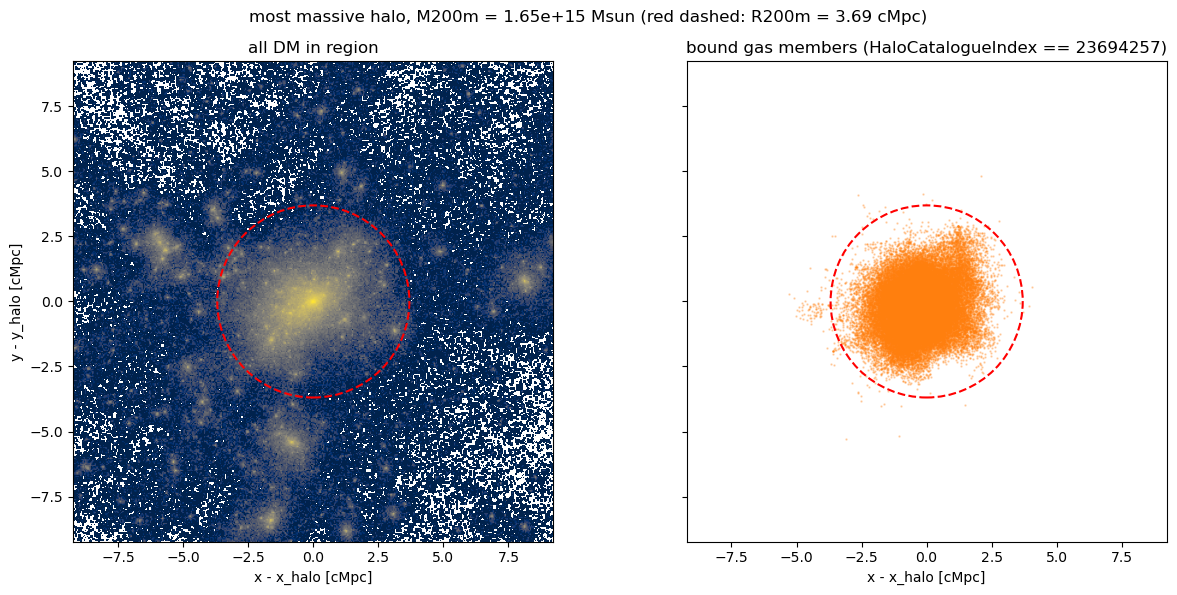

In [11]:
# Visual check: DM surface density around the halo, R200m circle, bound gas members
half = 2.5 * target_R
d_dm = periodic_delta(dm['Coordinates'], target_pos, boxsize)
d_gas_b = periodic_delta(gas['Coordinates'][bound_gas], target_pos, boxsize)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
hist, xe, ye_ = np.histogram2d(d_dm[:, 0], d_dm[:, 1], bins=400,
                               range=[[-half, half], [-half, half]], weights=dm['Masses'])
axes[0].imshow(hist.T, origin='lower', extent=[-half, half, -half, half],
               norm=LogNorm(), cmap='cividis')
axes[0].set_title('all DM in region')

sub = np.random.default_rng(0).choice(len(d_gas_b), size=min(50000, len(d_gas_b)), replace=False)
axes[1].scatter(d_gas_b[sub, 0], d_gas_b[sub, 1], s=0.5, alpha=0.3, c='C1')
axes[1].set_title(f'bound gas members (HaloCatalogueIndex == {target_idx})')

for ax in axes:
    ax.add_patch(plt.Circle((0, 0), target_R, fill=False, color='red', ls='--', lw=1.5))
    ax.set_xlim(-half, half)
    ax.set_ylim(-half, half)
    ax.set_xlabel('x - x_halo [cMpc]')
    ax.set_aspect('equal')
axes[0].set_ylabel('y - y_halo [cMpc]')
fig.suptitle(f'most massive halo, M200m = {halos["M200m"][t]:.2e} Msun '
             f'(red dashed: R200m = {target_R:.2f} cMpc)')
plt.tight_layout()
plt.show()

del gas, dm, d_dm


## 5. All three feedback variants

Quick check that the fiducial run and both feedback variants load identically.


In [12]:
print(f'{"variant":>16} {"z":>6} {"h":>6} {"N_gas":>14} {"N_halos":>10} '
      f'{"N(M200m>1e14)":>14} {"max M200m [Msun]":>17}')
for v in VARIANTS:
    with h5py.File(snap_file(v), 'r') as f:
        hdr = dict(f['Header'].attrs.items())
        cos = dict(f['Cosmology'].attrs.items())
        n_gas_v = int(hdr['NumPart_ThisFile'][0])
        z_v, h_v = float(hdr['Redshift'][0]), float(cos['h'][0])
    with h5py.File(soap_file(v), 'r') as f:
        m200m = f['SO/200_mean/TotalMass'][:].astype(np.float64) * 1e10
    print(f'{v:>16} {z_v:>6.3f} {h_v:>6.3f} {n_gas_v:>14,} {len(m200m):>10,} '
          f'{np.sum(m200m > 1e14):>14,} {m200m.max():>17.3e}')
    del m200m


         variant      z      h          N_gas    N_halos  N(M200m>1e14)  max M200m [Msun]


           L1_m9  0.500  0.681  5,364,099,453 17,677,657          7,050         1.651e+15


     fgas-8sigma  0.500  0.681  5,322,052,860 17,536,038          6,386         1.651e+15


 Jet_fgas-4sigma  0.500  0.681  5,337,511,093 17,466,425          6,421         1.646e+15


## Summary: conventions for the eventual `loadIO.py` integration

| item | FLAMINGO | repo convention | conversion |
|---|---|---|---|
| positions | cMpc, no h | ckpc/h | `* 1000 * h` |
| masses | 1e10 Msun, no h | Msun/h | `* 1e10 * h` |
| box size | `Header/BoxSize` in cMpc | ckpc/h | `* 1000 * h` |
| DM masses | per-particle `Masses` field (`MassTable` all zero) | like SIMBA | no MassTable trick needed |
| particle counts | `NumPart_Total` overflows 32 bits | — | use `NumPart_ThisFile` (or add HighWord) |
| halo centre | `InputHalos/HaloCentre` (cMpc) | `GroupPos` (ckpc/h) | `* 1000 * h` |
| halo mass | `SO/200_mean/TotalMass` (1e10 Msun) | `GroupMass` (Msun/h) | `* 1e10 * h` |
| halo radius | `SO/200_mean/SORadius` (cMpc) | `GroupRad` = R_Mean200 (ckpc/h) | `* 1000 * h` |
| halo membership | particle `HaloCatalogueIndex` == `InputHalos/HaloCatalogueIndex` | — | virtual file joins membership automatically |
| spatial subsets | `Cells` group (32^3 cells, offsets+counts) | — | see `read_cells()` above |
| cosmology | `Cosmology` attrs (h=0.681, Om=0.3046) | header dict | synthesize TNG-style header |
